In [2]:
import numpy as np
from sens_heat import SensHeat as Sens
from optimizer import DualMMA as Optimizer
from filtering import Projection, MaxLength
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta0 = 0.25 # 基準となるしきい値パラメータ
eta_dil = eta0 # 太くなるしきい値パラメータ
eta_mid = 0.5 # 中間のしきい値パラメータ
eta_ero = 1-eta0 # 細くなるしきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
r_ml = 8.0 # 最大寸法制約用無次元フィルタ半径
b_max = 3.0 # 最大寸法(最大幅/2)
p = 16 # 最大寸法制約用Pノルムパラメータ
opt = Optimizer(x, 2) # MMAの初期化: 制約2つ
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
def max_length_constraint(x, p, alpha):
    g = np.array([(np.sum(x**p)/len(x))**(1/p)/alpha-1]) # 最大寸法制約の関数
    gradg = np.array((np.sum(x**p)/len(x))**(1/p-1)*x**(p-1))[None,:]/(alpha*len(x)) # 最大寸法制約の勾配
    return g, gradg
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]] # ロバストトポロジー最適化用ヘビサイドプロジェクション
fil_dil, fil_mid, fil_ero = filters
fil_ml = MaxLength(sens.n1, sens.n2, r_ml, b_max) # 最大寸法制約用フィルタ
alpha = fil_ml.get_alpha() # 最大寸法制約における材料占有率
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters] # 太・中間・細の設計変数
    x_ml = fil_ml.apply(x_mid) # 最大寸法制約で用いるフィルタ後の設計変数
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx]) # 最悪値の目的関数とその感度を取得
    g1, gradg1_proj = volume_constraint(x_mid)
    g2, gradg2_ml = max_length_constraint(x_ml, p, alpha)
    gradg2_proj = fil_ml.modify_sensitivity_gradgi(gradg2_ml)
    fil_obj = filters[idx]
    gradf = fil_obj.modify_sensitivity_gradf(gradf_proj) # 最悪値での微分の連鎖律による目的関数の感度
    gradg1 = fil_mid.modify_sensitivity_gradgi(gradg1_proj) # 微分の連鎖律による制約関数1の感度
    gradg2 = fil_mid.modify_sensitivity_gradgi(gradg2_proj) # 微分の連鎖律による制約関数2の感度
    g, gradg = np.array([g1[0], g2[0]]), np.concatenate([gradg1, gradg2])
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g1 = {g[0]:.2e}, g2 = {g[1]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 5.01e+02, g1 = -1.36e-02, g2 = -3.85e-01, norm_inf_x = 5.0e-02, m_nd = 81.76
1 iters, f = 3.04e+02, g1 = 2.68e-03, g2 = -2.98e-01, norm_inf_x = 5.0e-02, m_nd = 83.56
2 iters, f = 2.01e+02, g1 = -4.66e-04, g2 = -2.17e-01, norm_inf_x = 5.0e-02, m_nd = 81.24
3 iters, f = 1.40e+02, g1 = -1.05e-04, g2 = -1.30e-01, norm_inf_x = 5.0e-02, m_nd = 79.14
4 iters, f = 1.03e+02, g1 = -3.46e-04, g2 = -3.91e-02, norm_inf_x = 5.0e-02, m_nd = 76.37
5 iters, f = 7.98e+01, g1 = -8.78e-04, g2 = 1.76e-02, norm_inf_x = 5.0e-02, m_nd = 74.15
6 iters, f = 6.68e+01, g1 = -1.57e-03, g2 = 2.68e-02, norm_inf_x = 5.0e-02, m_nd = 71.69
7 iters, f = 6.03e+01, g1 = -1.60e-03, g2 = 1.45e-02, norm_inf_x = 5.0e-02, m_nd = 71.32
8 iters, f = 5.51e+01, g1 = -1.53e-03, g2 = 2.13e-02, norm_inf_x = 5.0e-02, m_nd = 70.08
9 iters, f = 5.21e+01, g1 = -1.70e-03, g2 = 2.02e-02, norm_inf_x = 5.0e-02, m_nd = 69.54
10 iters, f = 4.97e+01, g1 = -1.74e-03, g2 = 2.27e-02, norm_inf_x = 5.0e-02, m_nd = 69.55
11 iters, f = 4.

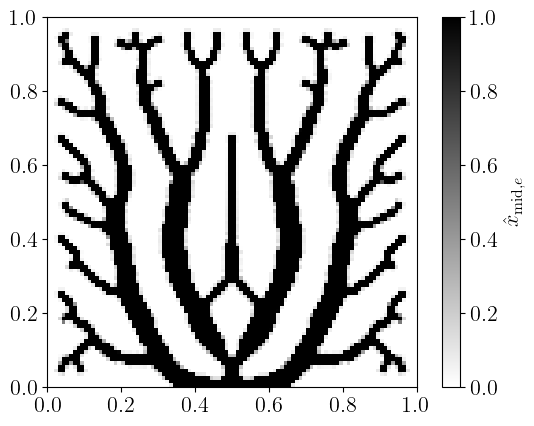

In [5]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x_mid.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_{\mathrm{mid},e}$')

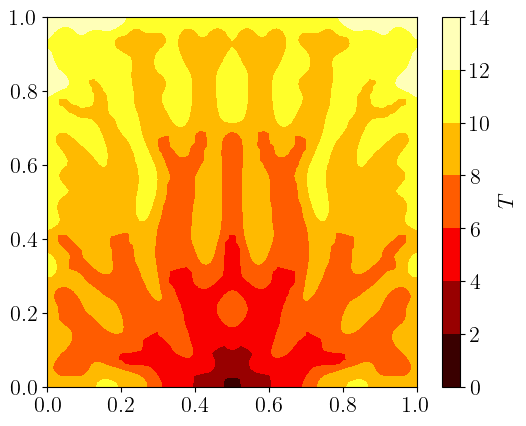

In [6]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1+1), np.linspace(0, sens.L2, sens.n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, sens.d.reshape((sens.n2+1, sens.n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')
plt.gca().set_aspect('equal')

In [1]:
import numpy as np
from sens_heat3d import SensHeat3D as Sens
from optimizer import DualMMA as Optimizer
from filtering3d import Projection
from scipy.special import erfinv
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.1 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2*sens.n3, V_MAX) # 設計変数の初期値
eta0 = 0.25 # 基準となるしきい値パラメータ
eta_dil = eta0 # 太くなるしきい値パラメータ
eta_mid = 0.5 # 中間のしきい値パラメータ
eta_ero = 1-eta0 # 細くなるしきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
b_min = 6.0 # 最小寸法
sigma = b_min/(2*np.sqrt(2)*erfinv(eta_ero)) # ガウシアンフィルタの影響範囲
opt = Optimizer(x, 1) 
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg
filters = [Projection(sens.n1, sens.n2, sens.n3, sigma, eta, beta0) for eta in [eta_mid, eta_ero]] # ロバストトポロジー最適化用ヘビサイドプロジェクション
fil_mid, fil_ero = filters
for itr in range(ITR_MAX+1):
    x_mid, x_ero = [fil.apply(itr, x) for fil in filters] # 中間・細の設計変数
    f, gradf_proj = sens.compute_obj_sens(x_ero) # 構造が細くなる場合の目的関数のみ評価
    g, gradg_proj = volume_constraint(x_mid)
    gradf = fil_ero.modify_sensitivity(gradf_proj) # 微分の連鎖律による目的関数の感度
    gradg = fil_mid.modify_sensitivity(gradg_proj, g=True) # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g1 = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 9.53e+04, g1 = -1.11e-02, norm_inf_x = 5.0e-02, m_nd = 32.40
1 iters, f = 5.50e+04, g1 = 1.14e-02, norm_inf_x = 5.0e-02, m_nd = 39.02
2 iters, f = 2.86e+04, g1 = 2.19e-02, norm_inf_x = 5.0e-02, m_nd = 40.50
3 iters, f = 1.53e+04, g1 = 2.18e-02, norm_inf_x = 5.0e-02, m_nd = 39.40
4 iters, f = 8.64e+03, g1 = 2.31e-02, norm_inf_x = 5.0e-02, m_nd = 38.40
5 iters, f = 5.20e+03, g1 = 2.08e-02, norm_inf_x = 5.0e-02, m_nd = 35.99
6 iters, f = 3.30e+03, g1 = 1.84e-02, norm_inf_x = 5.0e-02, m_nd = 33.50
7 iters, f = 2.19e+03, g1 = 1.63e-02, norm_inf_x = 5.0e-02, m_nd = 31.27
8 iters, f = 1.52e+03, g1 = 1.45e-02, norm_inf_x = 5.0e-02, m_nd = 29.50
9 iters, f = 1.09e+03, g1 = 1.33e-02, norm_inf_x = 5.0e-02, m_nd = 27.86
10 iters, f = 8.02e+02, g1 = 1.23e-02, norm_inf_x = 5.0e-02, m_nd = 26.32
11 iters, f = 6.08e+02, g1 = 1.13e-02, norm_inf_x = 5.0e-02, m_nd = 24.82
12 iters, f = 4.71e+02, g1 = 1.04e-02, norm_inf_x = 5.0e-02, m_nd = 23.35
13 iters, f = 3.74e+02, g1 = 9.48e-03, norm_inf

In [5]:
import pyvista as pv
from scipy import ndimage
def export_stl(sens, x, filename="result.stl", iso=0.5, sigma=1.0):
    d = x.reshape((sens.n1, sens.n2, sens.n3), order='F')
    d = np.concatenate([d[::-1], d], axis=0)
    d = np.concatenate([d[:, ::-1], d], axis=1)
    mask = d > iso
    d = np.pad(ndimage.gaussian_filter(mask.astype(float), sigma), 2)
    grid = pv.ImageData(dimensions=np.array(d.shape)+1, spacing=[sens.h]*3, origin=[-sens.h*(sens.n1+2), -sens.h*(sens.n2+2), -sens.h*2])    
    grid.cell_data["d"] = d.flatten(order='F')
    grid.cell_data_to_point_data().contour([iso], "d").smooth_taubin(n_iter=20, pass_band=0.1).save(filename)

In [3]:
export_stl(sens, x_mid)

In [4]:
import numpy as np
from sens_heat3d import SensHeat3D as Sens
from optimizer import DualMMA as Optimizer
from filtering3d import AMFilter
from scipy.special import erfinv
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2*sens.n3, V_MAX) # 設計変数の初期値
eta0 = 0.25 # 基準となるしきい値パラメータ
eta_dil = eta0 # 太くなるしきい値パラメータ
eta_mid = 0.5 # 中間のしきい値パラメータ
eta_ero = 1-eta0 # 細くなるしきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
b_min = 6.0 # 最小寸法
sigma = b_min/(2*np.sqrt(2)*erfinv(eta_ero)) # ガウシアンフィルタの影響範囲
opt = Optimizer(x, 1) 
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg
filters = [AMFilter(sens.n1, sens.n2, sens.n3, sigma, eta, beta0) for eta in [eta_mid, eta_ero]] # AMフィルタ
fil_mid, fil_ero = filters
for itr in range(ITR_MAX+1):
    x_mid, x_ero = [fil.apply(itr, x) for fil in filters] # 中間・細の設計変数
    f, gradf_proj = sens.compute_obj_sens(x_ero) # 構造が細くなる場合の目的関数のみ評価
    g, gradg_proj = volume_constraint(x_mid)
    gradf = fil_ero.modify_sensitivity(gradf_proj) # 微分の連鎖律による目的関数の感度
    gradg = fil_mid.modify_sensitivity(gradg_proj, g=True) # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g1 = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 8.55e+03, g1 = -2.28e-01, norm_inf_x = 5.0e-02, m_nd = 24.66
1 iters, f = 5.18e+03, g1 = -2.05e-01, norm_inf_x = 5.0e-02, m_nd = 30.68
2 iters, f = 3.30e+03, g1 = -1.60e-01, norm_inf_x = 5.0e-02, m_nd = 41.66
3 iters, f = 2.17e+03, g1 = 1.60e-02, norm_inf_x = 5.0e-02, m_nd = 79.06
4 iters, f = 1.49e+03, g1 = -5.33e-02, norm_inf_x = 5.0e-02, m_nd = 62.28
5 iters, f = 1.06e+03, g1 = -4.12e-02, norm_inf_x = 5.0e-02, m_nd = 65.09
6 iters, f = 7.70e+02, g1 = 1.81e-02, norm_inf_x = 5.0e-02, m_nd = 75.02
7 iters, f = 5.84e+02, g1 = -1.98e-02, norm_inf_x = 5.0e-02, m_nd = 66.70
8 iters, f = 4.47e+02, g1 = -1.69e-03, norm_inf_x = 5.0e-02, m_nd = 69.47
9 iters, f = 3.52e+02, g1 = -1.48e-02, norm_inf_x = 5.0e-02, m_nd = 66.10
10 iters, f = 2.81e+02, g1 = -8.16e-03, norm_inf_x = 5.0e-02, m_nd = 65.12
11 iters, f = 2.28e+02, g1 = -4.38e-03, norm_inf_x = 5.0e-02, m_nd = 63.68
12 iters, f = 1.88e+02, g1 = -3.59e-03, norm_inf_x = 5.0e-02, m_nd = 61.53
13 iters, f = 1.58e+02, g1 = -2.32e-0

In [6]:
export_stl(sens, x_mid, 'result_am.stl')